In [1]:
import os
import pandas as pd

In [7]:
vhh_file_path = "../data/abnativ_humanization/5m2jD_VHH_abnativ_seq_scores.csv"
vh_file_path = "../data/abnativ_humanization/5m2jD_VH_abnativ_seq_scores.csv"

vhh_df = pd.read_csv(
    vhh_file_path,
    usecols=['seq_id', 'AbNatiV VHH Score']
)
vh_df = pd.read_csv(
    vh_file_path,
    usecols=['seq_id', 'AbNatiV VH Score']
)

abnativ_df = pd.merge(vhh_df, vh_df, on='seq_id')
abnativ_df['group'] = abnativ_df['seq_id'].str.split('_').str[0]
abnativ_df['ID'] = abnativ_df['seq_id'].str.split('_').str[1:].str.join('_')

In [8]:
grafted_embedding_file_path = "../data/5m2jD_grafting_74A_94R_temp07_s50_250917/extract_distance/filter_best/grafted_raw_embeddings.tsv"

# grafted_embedding_file_path = "/data1/dhuang/Ig-fold/nanobody_db/humanization/5m2jD_grafting_74A_94R_temp07_s1000_250830/extract_distance_10/filter_avge/grafted_raw_embeddings.tsv"

grafted_df = pd.read_csv(grafted_embedding_file_path, sep='\t')

In [15]:
top_five_percent = int(0.05 * len(grafted_df))
top_10_percent = int(0.1 * len(grafted_df))
top_50_percent = int(0.5 * len(grafted_df))

In [21]:
top_n = top_10_percent
top_grafted_df = grafted_df.iloc[:top_n+1, :2]


In [22]:
top_grafted_abnativ_df = pd.merge(top_grafted_df, abnativ_df, how='inner', left_on='PDB_ID', right_on='ID')
# top_grafted_abnativ_df['group'] = 'LFFS-Ig'
# compare_abnativ_df = abnativ_df[abnativ_df['group'] != 'LFFS-Ig']

compare_abnativ_df = abnativ_df.iloc[:2, :]

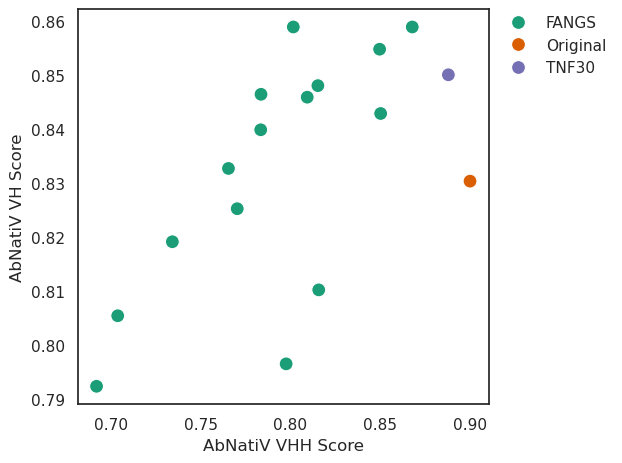

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

df = pd.concat([top_grafted_abnativ_df, compare_abnativ_df], ignore_index=True)

# 方法一：seaborn.scatterplot，自动处理图例和配色
sns.set(style="white")
palette = sns.color_palette('Dark2', n_colors=df['group'].nunique())
ax = sns.scatterplot(
    data=df,
    x='AbNatiV VHH Score',
    y='AbNatiV VH Score',
    hue='group',
    palette=palette,
    s=100,         # 点大小
    edgecolor="w" # 白色边框
)

ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# x_min, x_max = ax.get_xlim()
# y_min, y_max = ax.get_ylim()
# #   确定对角线的起止：从这两个范围的交集的最小值，到最大值
# lo = max(min(x_min, y_min), 0)  # 如果想从 0 开始，可改成 lo = 0
# hi = min(max(x_max, y_max), max(x_max, y_max))
# ax.plot([lo, hi], [lo, hi],
#         linestyle='--', linewidth=1, color='gray')

ax.legend(
    title=None,
    bbox_to_anchor=(1.02, 1),  # 图例左下角锚点：超出画布右侧 2% 处
    loc='upper left',
    borderaxespad=0,
    frameon=False
)

# ax.set_title("VHH vs VH Score by Group")
plt.tight_layout()

save_path = "../figures/abnativ_vhh_vh_score_scatterplot.png"
plt.savefig(save_path, dpi=600)

plt.show()

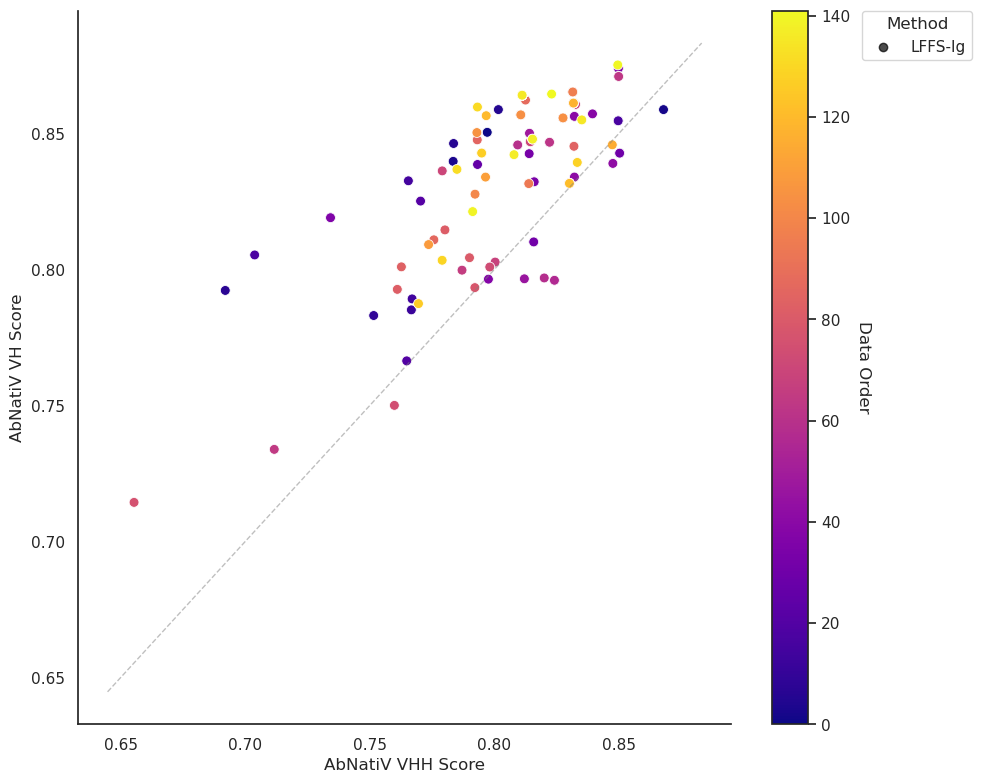

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# # 合并数据
# df = pd.concat([top_grafted_abnativ_df, compare_abnativ_df], ignore_index=True)
df = top_grafted_abnativ_df

# 创建一个表示数据顺序的列
df['order'] = range(len(df))

# 设置样式
sns.set(style="white")
plt.figure(figsize=(10, 8))

# 使用类似heatmap的颜色映射
cmap = plt.cm.plasma  # 可以替换为其他colormap，如 'plasma', 'inferno', 'magma', 'cividis'等

# 创建散点图，使用order列来确定颜色
scatter = ax = sns.scatterplot(
    data=df,
    x='AbNatiV VHH Score',
    y='AbNatiV VH Score',
    hue='order',  # 使用order列来映射颜色
    palette=cmap,  # 使用连续的颜色映射
    s=50,         # 点大小
    edgecolor="w", # 白色边框
    legend=False   # 不显示order的图例
)

# 添加颜色条
norm = plt.Normalize(df['order'].min(), df['order'].max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Data Order', rotation=270, labelpad=15)

# 添加对角线（如果需要）
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
lo = max(min(x_min, y_min), 0)
hi = min(max(x_max, y_max), max(x_max, y_max))
ax.plot([lo, hi], [lo, hi],
        linestyle='--', linewidth=1, color='gray', alpha=0.5)

# 添加group的图例（如果需要）
# 获取唯一的group值
unique_groups = df['group'].unique()
# 为每个group创建一个示例散点
for i, group in enumerate(unique_groups):
    ax.scatter([], [], c='black', label=group, alpha=0.7)
ax.legend(
    title='Method',
    bbox_to_anchor=(1.2, 1),
    loc='upper left',
    borderaxespad=0
)

# 美化图表
ax.set_xlabel('AbNatiV VHH Score', fontsize=12)
ax.set_ylabel('AbNatiV VH Score', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
